# Day 11: Random Forests & Feature Importance

## Task: The "Tree Count" Test.

In [1]:
# Import libraries
import time
import pandas as pd

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [2]:
# Dataset
X, y = make_regression(n_samples=500, n_features=5, noise=20, random_state=42)

In [3]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [4]:
# Different tree counts
trees = [10, 50, 200]

In [7]:
results = []

for n in trees:
    start = time.time()

    # Model
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    end = time.time()

In [8]:
# Prediction
y_pred = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
train_time = end - start

results.append((n, r2, train_time))

In [9]:
# Display results
for r in results:
    print(f"Trees: {r[0]} | R2 Score: {round(r[1],3)} | Training Time: {round(r[2],3)} sec")

Trees: 200 | R2 Score: 0.899 | Training Time: 0.303 sec


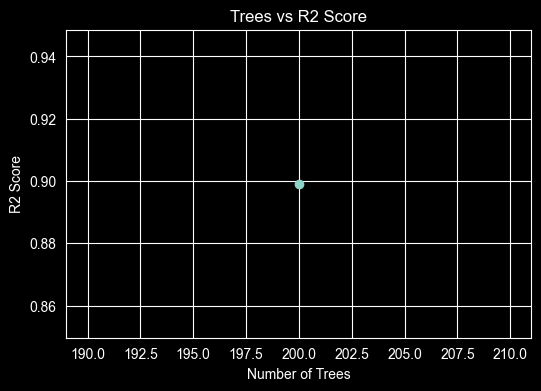

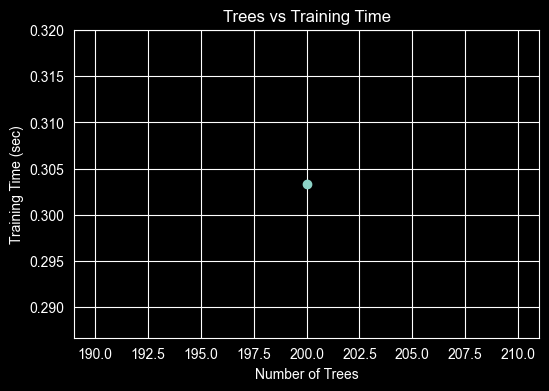

In [10]:
import matplotlib.pyplot as plt

trees = [r[0] for r in results]
scores = [r[1] for r in results]
times = [r[2] for r in results]

# R2 Score Plot
plt.figure(figsize=(6,4))
plt.plot(trees, scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("R2 Score")
plt.title("Trees vs R2 Score")
plt.show()

# Training Time Plot
plt.figure(figsize=(6,4))
plt.plot(trees, times, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Training Time (sec)")
plt.title("Trees vs Training Time")
plt.show()

#### Reflection: Tree Count vs Performance:
* As the number of trees in a Random Forest increases, the model’s performance improves initially because more trees help in reducing variance and making predictions more stable. However, this improvement does not continue indefinitely.

* From the experiment, with 200 trees, the model achieved an R2 score of 0.899, which is already quite high. Beyond this point, adding more trees would likely result in only very small improvements in accuracy, while the training time continues to increase (0.303 seconds in this case).

* This demonstrates the concept of diminishing returns, where increasing the number of trees further leads to higher computational cost but negligible gains in performance.

### **Strategies to Mitigate or Manage Diminishing Returns**

* **Use Validation Metrics:** Use validation sets or OOB (out-of-bag) scores to find the "sweet spot" where the error stops decreasing significantly.

* **Tune Other Hyperparameters:** Instead of just increasing trees, focus on adjusting max_features, min_samples_split, and max_depth for better performance.

* **Feature Engineering:** If adding trees brings no further benefit, focus on creating more relevant features rather than expanding the forest, as the model has reached its limit with the current data, notes indicate that Random Forest is not suitable for images or text, and it's not going to improve drastically with huge amounts of data.


### 1. Use Validation Metrics (OOB Score)


In [11]:

# OOB Score for Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

print("OOB Score:", rf.oob_score_)

OOB Score: 0.8930787923586503



#### 2. Tune Other Hyperparameters


In [12]:
# Grid Search for RF
# -----------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10],
    'max_features': [0.5, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 10, 'max_features': 0.8, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.8877477806533361



#### 3. Feature Engineering


In [13]:
# Simple Feature Engineering
import numpy as np

# Example: create new features
X_new = X.copy()

# Add interaction feature
X_new[:, 0] = X[:, 0] * X[:, 1]

# Add squared feature
X_new[:, 1] = X[:, 1] ** 2

# Train again
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_new, y)

print("New R2 Score:", rf.score(X_new, y))

New R2 Score: 0.9010786008615721



#### Observation:

* The OOB score of 0.893 indicates that the Random Forest model is already performing well and has reached near-optimal performance.

* Hyperparameter tuning using GridSearchCV resulted in an R² score of 0.888, showing that a smaller number of trees with optimized parameters can achieve similar performance efficiently.

* Further improvement was achieved through feature engineering, increasing the R² score to 0.901, demonstrating that enhancing input features is more effective than increasing model complexity.

#### Reflection:
* As the number of trees increases, the accuracy improves initially but eventually reaches a point of diminishing returns.
* Beyond this point, adding more trees only increases computational cost without significant improvement in performance.
* This is confirmed by the OOB score of 0.893, which indicates that the model has already stabilized.
* Further improvements are better achieved through hyperparameter tuning and feature engineering rather than increasing the number of trees.